# Rotten Tomatoes Tomatometer Nowcasting Model

**Goal:** Given partial incoming critic reviews for a movie, estimate the expected final Tomatometer  
score (% Fresh) with uncertainty via Monte Carlo simulation.

**Approach:**  
1. **Selection model** — predict which critics will review a movie  
2. **Outcome model** — predict whether a review will be Fresh (given review happens)  
3. **Combine** via Monte Carlo for live nowcasting with uncertainty intervals

## 0. Configuration & Settings

In [1]:
# ============================================================
# CONFIGURATION — edit these before running
# ============================================================

CSV_PATH = "rotten_tomatoes_critic_reviews.csv"

# Column name mapping — map YOUR csv columns to expected names.
# Keys = expected name, Values = actual column name in your CSV.
# Set value to None if the column doesn't exist.
COLUMN_MAP = {
    "movie_id":        "rotten_tomatoes_link",
    "critic_name":     "critic_name",
    "outlet":          "publisher_name",
    "review_date":     "review_date",
    "review_type":     "review_type",       # "Fresh"/"Rotten" string
    "is_fresh":        None,                 # set if you have a 1/0 column directly
    "review_score":    "review_score",
    "is_top_critic":   "top_critic",
    "movie_genres":    None,                 # e.g. "Action|Comedy"
    "wide_release_date": None,
    "runtime":         None,
    "mpaa_rating":     None,
    "studio":          None,
    "director":        None,
    "cast":            None,
}

# Modeling parameters
NEGATIVE_RATIO = 10          # negatives per positive for selection model training
MIN_REVIEWS_PER_MOVIE = 20   # only model movies with enough reviews
MIN_REVIEWS_PER_CRITIC = 5   # only include critics with enough history
CUTOFF_DATE = "2019-01-01"   # train < cutoff, validate >= cutoff
N_SIMS = 10_000              # Monte Carlo simulations for nowcast
THRESHOLDS = [0.60, 0.70, 0.80, 0.90]
TOP_N_GENRES = 15            # number of genre columns to keep (if genres available)
RANDOM_SEED = 42

# Backtest checkpoints (number of reviews seen)
BACKTEST_CHECKPOINTS = [5, 10, 25, 50]

# Max critics in universe (cap for memory; set None for no cap)
MAX_CRITICS_UNIVERSE = 3000

## 1. Imports & Data Loading

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from collections import defaultdict

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score, log_loss, brier_score_loss,
    mean_absolute_error, mean_squared_error
)
from sklearn.preprocessing import StandardScaler

try:
    import lightgbm as lgb
    USE_LGBM = True
    print("Using LightGBM")
except ImportError:
    USE_LGBM = False
    print("LightGBM not found — falling back to LogisticRegression")

np.random.seed(RANDOM_SEED)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

print("Imports OK")

LightGBM not found — falling back to LogisticRegression
Imports OK


In [3]:
# ── Load CSV ──────────────────────────────────────────────
raw = pd.read_csv(CSV_PATH)
print(f"Loaded {len(raw):,} rows, {raw.shape[1]} columns")
print(f"Columns: {list(raw.columns)}")
raw.head(3)

Loaded 1,130,017 rows, 8 columns
Columns: ['rotten_tomatoes_link', 'critic_name', 'top_critic', 'publisher_name', 'review_type', 'review_score', 'review_date', 'review_content']


,rotten_tomatoes_link,critic_name,top_critic,publisher_name,review_type,review_score,review_date,review_content
0,m/0814255,Andrew L. Urban,False,Urban Cinefile,Fresh,NaN,2010-02-06,A fantasy adventure that fuses Greek mythology...
1,m/0814255,Louise Keller,False,Urban Cinefile,Fresh,NaN,2010-02-06,"Uma Thurman as Medusa, the gorgon with a coiff..."
2,m/0814255,NaN,False,FILMINK (Australia),Fresh,NaN,2010-02-09,With a top-notch cast and dazzling special eff...


In [4]:
# ── Map columns to standard names ────────────────────────
def safe_rename(df, mapping):
    """Rename columns based on mapping dict, skipping Nones and missing cols."""
    rename_dict = {}
    for std_name, csv_name in mapping.items():
        if csv_name is not None and csv_name in df.columns and csv_name != std_name:
            rename_dict[csv_name] = std_name
    return df.rename(columns=rename_dict)

df = safe_rename(raw.copy(), COLUMN_MAP)

# Ensure required columns exist
required = ["movie_id", "review_date"]
for col in required:
    mapped = COLUMN_MAP.get(col)
    actual = col if col in df.columns else mapped
    assert actual in df.columns, f"Missing required column: {col} (mapped to {mapped})"

print("Standardized columns:", list(df.columns))

Standardized columns: ['movie_id', 'critic_name', 'is_top_critic', 'outlet', 'review_type', 'review_score', 'review_date', 'review_content']


### 1a. Cleaning

In [5]:
# ── Parse dates ───────────────────────────────────────────
df["review_date"] = pd.to_datetime(df["review_date"], errors="coerce")

# Drop rows with no date or absurd dates
df = df[df["review_date"].notna()].copy()
df = df[df["review_date"] >= "1990-01-01"].copy()
df = df[df["review_date"] <= "2021-01-01"].copy()

# ── Standardize critic_name ───────────────────────────────
if "critic_name" in df.columns:
    df["critic_name"] = df["critic_name"].astype(str).str.strip().str.lower()
    df = df[df["critic_name"] != "nan"].copy()
else:
    raise ValueError("No critic_name column found")

# ── Create is_fresh ───────────────────────────────────────
if "is_fresh" not in df.columns or df["is_fresh"].isna().all():
    if "review_type" in df.columns:
        df["is_fresh"] = (df["review_type"].str.strip().str.lower() == "fresh").astype(int)
    else:
        raise ValueError("Need either is_fresh or review_type column")

df["is_fresh"] = df["is_fresh"].astype(int)

# ── Standardize is_top_critic ─────────────────────────────
if "is_top_critic" in df.columns:
    df["is_top_critic"] = df["is_top_critic"].map(
        {True: 1, False: 0, "True": 1, "False": 0, 1: 1, 0: 0}
    ).fillna(0).astype(int)
else:
    df["is_top_critic"] = 0

# ── Parse genres (if available) ───────────────────────────
HAS_GENRES = "movie_genres" in df.columns and df["movie_genres"].notna().any()
if HAS_GENRES:
    df["movie_genres"] = df["movie_genres"].fillna("")
    # Explode to find top genres
    all_genres = df["movie_genres"].str.split("|").explode().str.strip().str.lower()
    all_genres = all_genres[all_genres != ""]
    top_genres = all_genres.value_counts().head(TOP_N_GENRES).index.tolist()
    for g in top_genres:
        df[f"genre_{g}"] = df["movie_genres"].str.lower().str.contains(g, na=False).astype(int)
    GENRE_COLS = [f"genre_{g}" for g in top_genres]
    print(f"Parsed {len(GENRE_COLS)} genre columns")
else:
    GENRE_COLS = []
    print("No genre data available — skipping genre features")

# ── Create movie_key ──────────────────────────────────────
df["movie_key"] = df["movie_id"].astype(str)

# ── Summary ───────────────────────────────────────────────
print(f"\nCleaned dataset: {len(df):,} reviews")
print(f"  Movies:  {df['movie_key'].nunique():,}")
print(f"  Critics: {df['critic_name'].nunique():,}")
print(f"  Date range: {df['review_date'].min().date()} to {df['review_date'].max().date()}")
print(f"  Fresh rate: {df['is_fresh'].mean():.3f}")

No genre data available — skipping genre features

Cleaned dataset: 1,111,270 reviews
  Movies:  17,711
  Critics: 11,108
  Date range: 1990-01-01 to 2020-10-29
  Fresh rate: 0.638


## 2. Critic Universe & Movie-Level Aggregates

In [6]:
# ── Movie-level stats ─────────────────────────────────────
movie_stats = df.groupby("movie_key").agg(
    n_reviews=("is_fresh", "size"),
    n_fresh=("is_fresh", "sum"),
    first_review=("review_date", "min"),
    last_review=("review_date", "max"),
    pct_top_critic=("is_top_critic", "mean"),
).reset_index()
movie_stats["tomatometer"] = movie_stats["n_fresh"] / movie_stats["n_reviews"]

# Filter to movies with enough reviews
movie_stats = movie_stats[movie_stats["n_reviews"] >= MIN_REVIEWS_PER_MOVIE].copy()
valid_movies = set(movie_stats["movie_key"])
df = df[df["movie_key"].isin(valid_movies)].copy()

print(f"Movies with >= {MIN_REVIEWS_PER_MOVIE} reviews: {len(valid_movies):,}")
print(f"Reviews retained: {len(df):,}")

Movies with >= 20 reviews: 11,060
Reviews retained: 1,040,644


In [7]:
# ── Build critic universe ─────────────────────────────────
critic_counts = df.groupby("critic_name").size().reset_index(name="n_movies_reviewed")
critic_counts = critic_counts[critic_counts["n_movies_reviewed"] >= MIN_REVIEWS_PER_CRITIC]

# Cap universe size for memory
if MAX_CRITICS_UNIVERSE and len(critic_counts) > MAX_CRITICS_UNIVERSE:
    critic_counts = critic_counts.nlargest(MAX_CRITICS_UNIVERSE, "n_movies_reviewed")

CRITIC_UNIVERSE = sorted(critic_counts["critic_name"].tolist())
critic_to_idx = {c: i for i, c in enumerate(CRITIC_UNIVERSE)}
n_critics = len(CRITIC_UNIVERSE)

print(f"Critic universe: {n_critics:,} critics")
print(f"  Min reviews: {critic_counts['n_movies_reviewed'].min()}")
print(f"  Median reviews: {critic_counts['n_movies_reviewed'].median():.0f}")
print(f"  Max reviews: {critic_counts['n_movies_reviewed'].max()}")

Critic universe: 3,000 critics
  Min reviews: 23
  Median reviews: 115
  Max reviews: 5710


## 3. Time-Based Train / Validation Split

In [8]:
# ── Split movies by first review date ────────────────────
cutoff = pd.Timestamp(CUTOFF_DATE)

train_movies = set(movie_stats[movie_stats["first_review"] < cutoff]["movie_key"])
val_movies = set(movie_stats[movie_stats["first_review"] >= cutoff]["movie_key"])

df_train = df[df["movie_key"].isin(train_movies)].copy()
df_val = df[df["movie_key"].isin(val_movies)].copy()

# Only keep reviews from universe critics
df_train_univ = df_train[df_train["critic_name"].isin(critic_to_idx)].copy()
df_val_univ = df_val[df_val["critic_name"].isin(critic_to_idx)].copy()

print(f"Train: {len(train_movies):,} movies, {len(df_train):,} reviews ({len(df_train_univ):,} from universe critics)")
print(f"Val:   {len(val_movies):,} movies, {len(df_val):,} reviews ({len(df_val_univ):,} from universe critics)")

Train: 10,501 movies, 976,106 reviews (945,592 from universe critics)
Val:   559 movies, 64,538 reviews (60,180 from universe critics)


## 4. Feature Engineering

In [9]:
def build_critic_features(reviews_df, critic_list):
    """
    Build critic-level features from a set of reviews.
    Only uses data in reviews_df (no leakage).
    """
    # Filter to universe critics
    rev = reviews_df[reviews_df["critic_name"].isin(critic_list)].copy()
    
    # Basic aggregates
    cstats = rev.groupby("critic_name").agg(
        critic_n_reviews=("is_fresh", "size"),
        critic_n_fresh=("is_fresh", "sum"),
        critic_n_movies=("movie_key", "nunique"),
        critic_first_review=("review_date", "min"),
        critic_last_review=("review_date", "max"),
        critic_is_top=("is_top_critic", "max"),
    ).reset_index()
    
    # Derived features
    cstats["critic_fresh_rate"] = cstats["critic_n_fresh"] / cstats["critic_n_reviews"]
    career_days = (cstats["critic_last_review"] - cstats["critic_first_review"]).dt.days.clip(lower=30)
    cstats["critic_review_rate_per_year"] = cstats["critic_n_reviews"] / (career_days / 365.25)
    
    # Genre-specific fresh rates (if genres available)
    if GENRE_COLS:
        for gc in GENRE_COLS:
            g_rev = rev[rev[gc] == 1]
            g_stats = g_rev.groupby("critic_name")["is_fresh"].mean().reset_index()
            g_stats.columns = ["critic_name", f"critic_fresh_{gc}"]
            cstats = cstats.merge(g_stats, on="critic_name", how="left")
            cstats[f"critic_fresh_{gc}"] = cstats[f"critic_fresh_{gc}"].fillna(cstats["critic_fresh_rate"])
    
    # Fill missing critics with global averages
    all_critics_df = pd.DataFrame({"critic_name": critic_list})
    cstats = all_critics_df.merge(cstats, on="critic_name", how="left")
    
    # Fill NaN for critics not in training data
    fill_vals = {
        "critic_n_reviews": 0, "critic_n_fresh": 0, "critic_n_movies": 0,
        "critic_is_top": 0,
        "critic_fresh_rate": rev["is_fresh"].mean(),
        "critic_review_rate_per_year": 0,
    }
    for gc in GENRE_COLS:
        fill_vals[f"critic_fresh_{gc}"] = rev["is_fresh"].mean()
    cstats = cstats.fillna(fill_vals)
    
    drop_cols = ["critic_first_review", "critic_last_review"]
    cstats = cstats.drop(columns=[c for c in drop_cols if c in cstats.columns])
    
    return cstats


def build_movie_features(reviews_df, movie_keys):
    """
    Build movie-level features from reviews data.
    """
    rev = reviews_df[reviews_df["movie_key"].isin(movie_keys)].copy()
    
    mstats = rev.groupby("movie_key").agg(
        movie_n_reviews=("is_fresh", "size"),
        movie_fresh_rate=("is_fresh", "mean"),
        movie_pct_top_critic=("is_top_critic", "mean"),
        movie_n_unique_outlets=("outlet", "nunique") if "outlet" in rev.columns else ("critic_name", "nunique"),
        movie_first_review=("review_date", "min"),
    ).reset_index()
    
    mstats["movie_release_month"] = mstats["movie_first_review"].dt.month
    mstats["movie_release_quarter"] = mstats["movie_first_review"].dt.quarter
    mstats["movie_release_year"] = mstats["movie_first_review"].dt.year
    
    # Add genre info if available (movie-level, take first row per movie)
    if GENRE_COLS:
        genre_info = rev.groupby("movie_key")[GENRE_COLS].max().reset_index()
        mstats = mstats.merge(genre_info, on="movie_key", how="left")
    
    mstats = mstats.drop(columns=["movie_first_review"])
    return mstats


# Build features from TRAINING data only
print("Building critic features from training data...")
critic_features = build_critic_features(df_train, CRITIC_UNIVERSE)
print(f"  Critic feature shape: {critic_features.shape}")

print("Building movie features...")
# For training movies, use train data; for val movies, also use train data (avoid leakage)
all_movie_keys = list(train_movies | val_movies)
movie_features = build_movie_features(df_train, train_movies)
# For val movies, build from val data (the reviews that exist — this is their actual data)
movie_features_val = build_movie_features(df_val, val_movies)
movie_features_all = pd.concat([movie_features, movie_features_val], ignore_index=True)
print(f"  Movie feature shape: {movie_features_all.shape}")

critic_features.head()

Building critic features from training data...
  Critic feature shape: (3000, 7)
Building movie features...
  Movie feature shape: (11060, 8)


,critic_name,critic_n_reviews,critic_n_fresh,critic_n_movies,critic_is_top,critic_fresh_rate,critic_review_rate_per_year
0,a.a. dowd,645.0,395.0,592.0,1.0,0.612403,75.653902
1,a.d. murphy,23.0,21.0,21.0,1.0,0.913043,2.086106
2,a.h. weiler,42.0,32.0,35.0,1.0,0.761905,5.380744
3,a.o. scott,2069.0,1322.0,1849.0,1.0,0.638956,104.944070
4,a.s. hamrah,230.0,127.0,208.0,0.0,0.552174,11.936275


## 5. Selection Model Training Data (Negative Sampling)

In [10]:
def build_selection_dataset(reviews_df, movie_keys, critic_list, neg_ratio, seed=42):
    """
    Build a binary dataset: did critic c review movie m?
    Uses negative sampling to keep size manageable.
    """
    rng = np.random.RandomState(seed)
    critic_set = set(critic_list)
    
    # Build observed (positive) pairs
    rev = reviews_df[
        reviews_df["movie_key"].isin(movie_keys) &
        reviews_df["critic_name"].isin(critic_set)
    ][["movie_key", "critic_name"]].drop_duplicates()
    
    pos_pairs = set(zip(rev["movie_key"], rev["critic_name"]))
    print(f"  Positive pairs: {len(pos_pairs):,}")
    
    # Build positive rows
    rows = [(m, c, 1) for m, c in pos_pairs]
    
    # Negative sampling: for each movie, sample neg_ratio * n_pos critics who did NOT review
    movie_to_reviewers = rev.groupby("movie_key")["critic_name"].apply(set).to_dict()
    critic_arr = np.array(critic_list)
    
    neg_count = 0
    for mk in movie_keys:
        reviewed_by = movie_to_reviewers.get(mk, set())
        n_pos = len(reviewed_by)
        if n_pos == 0:
            continue
        n_neg = min(n_pos * neg_ratio, len(critic_list) - n_pos)
        if n_neg <= 0:
            continue
        
        # Find non-reviewers
        non_reviewers = [c for c in critic_list if c not in reviewed_by]
        if len(non_reviewers) > n_neg:
            chosen = rng.choice(non_reviewers, size=n_neg, replace=False)
        else:
            chosen = non_reviewers
        
        for c in chosen:
            rows.append((mk, c, 0))
            neg_count += 1
    
    result = pd.DataFrame(rows, columns=["movie_key", "critic_name", "reviewed"])
    print(f"  Negative pairs: {neg_count:,}")
    print(f"  Total selection dataset: {len(result):,} rows")
    return result


print("Building TRAIN selection dataset...")
sel_train = build_selection_dataset(df_train, list(train_movies), CRITIC_UNIVERSE, NEGATIVE_RATIO, seed=RANDOM_SEED)

print("\nBuilding VAL selection dataset...")
sel_val = build_selection_dataset(df_val, list(val_movies), CRITIC_UNIVERSE, NEGATIVE_RATIO, seed=RANDOM_SEED + 1)

Building TRAIN selection dataset...
  Positive pairs: 837,527
  Negative pairs: 8,247,095
  Total selection dataset: 9,084,622 rows

Building VAL selection dataset...
  Positive pairs: 53,417
  Negative pairs: 490,823
  Total selection dataset: 544,240 rows


In [11]:
def merge_features(sel_df, critic_feats, movie_feats):
    """Merge critic and movie features into a selection dataset."""
    merged = sel_df.merge(critic_feats, on="critic_name", how="left")
    merged = merged.merge(movie_feats, on="movie_key", how="left")
    return merged

sel_train_feat = merge_features(sel_train, critic_features, movie_features_all)
sel_val_feat = merge_features(sel_val, critic_features, movie_features_all)

# Define feature columns (everything except identifiers and target)
META_COLS = ["movie_key", "critic_name", "reviewed"]
FEATURE_COLS = [c for c in sel_train_feat.columns if c not in META_COLS]

# Fill any remaining NaN with 0
sel_train_feat[FEATURE_COLS] = sel_train_feat[FEATURE_COLS].fillna(0)
sel_val_feat[FEATURE_COLS] = sel_val_feat[FEATURE_COLS].fillna(0)

print(f"Feature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"Train shape: {sel_train_feat.shape}")
print(f"Val shape:   {sel_val_feat.shape}")

Feature columns (13): ['critic_n_reviews', 'critic_n_fresh', 'critic_n_movies', 'critic_is_top', 'critic_fresh_rate', 'critic_review_rate_per_year', 'movie_n_reviews', 'movie_fresh_rate', 'movie_pct_top_critic', 'movie_n_unique_outlets', 'movie_release_month', 'movie_release_quarter', 'movie_release_year']
Train shape: (9084622, 16)
Val shape:   (544240, 16)


## 6. Model A: Selection Model (Who Will Review?)

In [12]:
X_sel_train = sel_train_feat[FEATURE_COLS].values
y_sel_train = sel_train_feat["reviewed"].values
X_sel_val = sel_val_feat[FEATURE_COLS].values
y_sel_val = sel_val_feat["reviewed"].values

print(f"Selection model — Train: {len(y_sel_train):,} (pos rate: {y_sel_train.mean():.4f})")
print(f"Selection model — Val:   {len(y_sel_val):,} (pos rate: {y_sel_val.mean():.4f})")

if USE_LGBM:
    sel_base = lgb.LGBMClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_samples=50,
        scale_pos_weight=(1 - y_sel_train.mean()) / y_sel_train.mean(),
        random_state=RANDOM_SEED,
        verbose=-1,
    )
else:
    scaler_sel = StandardScaler()
    X_sel_train = scaler_sel.fit_transform(X_sel_train)
    X_sel_val = scaler_sel.transform(X_sel_val)
    sel_base = LogisticRegression(
        C=1.0, class_weight="balanced", max_iter=1000, random_state=RANDOM_SEED
    )

# Calibrate
print("Training selection model...")
sel_model = CalibratedClassifierCV(sel_base, cv=3, method="isotonic")
sel_model.fit(X_sel_train, y_sel_train)

# Evaluate
sel_proba_train = sel_model.predict_proba(X_sel_train)[:, 1]
sel_proba_val = sel_model.predict_proba(X_sel_val)[:, 1]

print(f"\n{'='*50}")
print(f"SELECTION MODEL RESULTS")
print(f"{'='*50}")
print(f"  Train AUC:      {roc_auc_score(y_sel_train, sel_proba_train):.4f}")
print(f"  Val AUC:        {roc_auc_score(y_sel_val, sel_proba_val):.4f}")
print(f"  Train Log Loss: {log_loss(y_sel_train, sel_proba_train):.4f}")
print(f"  Val Log Loss:   {log_loss(y_sel_val, sel_proba_val):.4f}")

Selection model — Train: 9,084,622 (pos rate: 0.0922)
Selection model — Val:   544,240 (pos rate: 0.0981)
Training selection model...

SELECTION MODEL RESULTS
  Train AUC:      0.8541
  Val AUC:        0.6513
  Train Log Loss: 0.2252
  Val Log Loss:   0.3175


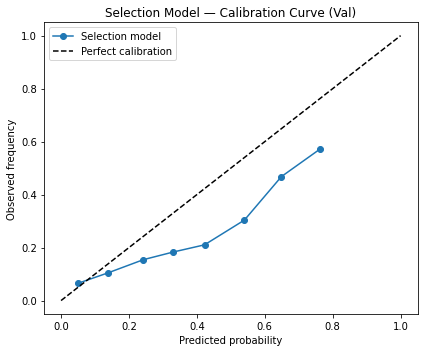

In [13]:
# ── Calibration curve for selection model ─────────────────
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
prob_true, prob_pred = calibration_curve(y_sel_val, sel_proba_val, n_bins=10)
ax.plot(prob_pred, prob_true, "o-", label="Selection model")
ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax.set_xlabel("Predicted probability")
ax.set_ylabel("Observed frequency")
ax.set_title("Selection Model — Calibration Curve (Val)")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Model B: Outcome Model (Fresh or Rotten?)

In [14]:
# ── Build outcome training data (only observed reviews) ───
def build_outcome_dataset(reviews_df, movie_keys, critic_list, critic_feats, movie_feats):
    """Build dataset for outcome model: only rows where critic actually reviewed."""
    critic_set = set(critic_list)
    rev = reviews_df[
        reviews_df["movie_key"].isin(movie_keys) &
        reviews_df["critic_name"].isin(critic_set)
    ][["movie_key", "critic_name", "is_fresh"]].drop_duplicates(
        subset=["movie_key", "critic_name"], keep="first"
    )
    rev = rev.merge(critic_feats, on="critic_name", how="left")
    rev = rev.merge(movie_feats, on="movie_key", how="left")
    return rev

out_train = build_outcome_dataset(df_train, list(train_movies), CRITIC_UNIVERSE, critic_features, movie_features_all)
out_val = build_outcome_dataset(df_val, list(val_movies), CRITIC_UNIVERSE, critic_features, movie_features_all)

OUT_FEATURE_COLS = [c for c in out_train.columns if c not in ["movie_key", "critic_name", "is_fresh"]]

out_train[OUT_FEATURE_COLS] = out_train[OUT_FEATURE_COLS].fillna(0)
out_val[OUT_FEATURE_COLS] = out_val[OUT_FEATURE_COLS].fillna(0)

print(f"Outcome train: {len(out_train):,} reviews (fresh rate: {out_train['is_fresh'].mean():.3f})")
print(f"Outcome val:   {len(out_val):,} reviews (fresh rate: {out_val['is_fresh'].mean():.3f})")

Outcome train: 837,527 reviews (fresh rate: 0.636)
Outcome val:   53,417 reviews (fresh rate: 0.694)


In [15]:
X_out_train = out_train[OUT_FEATURE_COLS].values
y_out_train = out_train["is_fresh"].values
X_out_val = out_val[OUT_FEATURE_COLS].values
y_out_val = out_val["is_fresh"].values

if USE_LGBM:
    out_base = lgb.LGBMClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_samples=50,
        random_state=RANDOM_SEED,
        verbose=-1,
    )
else:
    scaler_out = StandardScaler()
    X_out_train = scaler_out.fit_transform(X_out_train)
    X_out_val = scaler_out.transform(X_out_val)
    out_base = LogisticRegression(
        C=1.0, max_iter=1000, random_state=RANDOM_SEED
    )

print("Training outcome model...")
out_model = CalibratedClassifierCV(out_base, cv=3, method="isotonic")
out_model.fit(X_out_train, y_out_train)

out_proba_train = out_model.predict_proba(X_out_train)[:, 1]
out_proba_val = out_model.predict_proba(X_out_val)[:, 1]

print(f"\n{'='*50}")
print(f"OUTCOME MODEL RESULTS")
print(f"{'='*50}")
print(f"  Train AUC:      {roc_auc_score(y_out_train, out_proba_train):.4f}")
print(f"  Val AUC:        {roc_auc_score(y_out_val, out_proba_val):.4f}")
print(f"  Train Log Loss: {log_loss(y_out_train, out_proba_train):.4f}")
print(f"  Val Log Loss:   {log_loss(y_out_val, out_proba_val):.4f}")

Training outcome model...

OUTCOME MODEL RESULTS
  Train AUC:      0.8388
  Val AUC:        0.8281
  Train Log Loss: 0.4713
  Val Log Loss:   0.4594


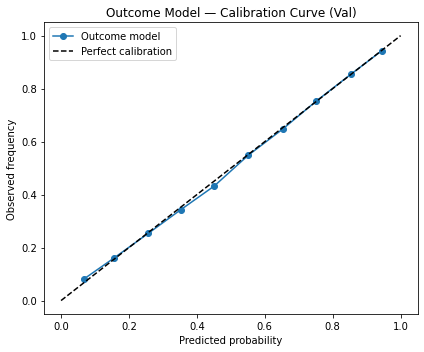

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
prob_true_o, prob_pred_o = calibration_curve(y_out_val, out_proba_val, n_bins=10)
ax.plot(prob_pred_o, prob_true_o, "o-", label="Outcome model")
ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax.set_xlabel("Predicted probability")
ax.set_ylabel("Observed frequency")
ax.set_title("Outcome Model — Calibration Curve (Val)")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Combine: Expected Final Tomatometer

In [17]:
def predict_selection_proba(movie_key, critic_list, critic_feats, movie_feats):
    """
    For a movie, predict P(review) for each critic in critic_list.
    Returns array of shape (len(critic_list),).
    """
    mf = movie_feats[movie_feats["movie_key"] == movie_key]
    if len(mf) == 0:
        return np.full(len(critic_list), 0.01)  # fallback
    
    cf = critic_feats[critic_feats["critic_name"].isin(critic_list)].copy()
    cf = cf.set_index("critic_name").loc[critic_list].reset_index()  # maintain order
    
    # Cross join
    cf["_key"] = 1
    mf_row = mf.iloc[[0]].copy()
    mf_row["_key"] = 1
    merged = cf.merge(mf_row.drop(columns=["movie_key"]), on="_key").drop(columns=["_key"])
    
    X = merged.drop(columns=["critic_name"]).fillna(0).values
    
    if not USE_LGBM and hasattr(sel_model, 'estimators_'):
        # If we used scaler, need to transform
        try:
            X = scaler_sel.transform(X)
        except:
            pass
    
    return sel_model.predict_proba(X)[:, 1]


def predict_outcome_proba(movie_key, critic_list, critic_feats, movie_feats):
    """
    For a movie, predict P(fresh | reviewed) for each critic.
    Returns array of shape (len(critic_list),).
    """
    mf = movie_feats[movie_feats["movie_key"] == movie_key]
    if len(mf) == 0:
        return np.full(len(critic_list), 0.5)  # fallback
    
    cf = critic_feats[critic_feats["critic_name"].isin(critic_list)].copy()
    cf = cf.set_index("critic_name").loc[critic_list].reset_index()
    
    cf["_key"] = 1
    mf_row = mf.iloc[[0]].copy()
    mf_row["_key"] = 1
    merged = cf.merge(mf_row.drop(columns=["movie_key"]), on="_key").drop(columns=["_key"])
    
    feat_cols = [c for c in merged.columns if c != "critic_name"]
    X = merged[feat_cols].fillna(0).values
    
    if not USE_LGBM:
        try:
            X = scaler_out.transform(X)
        except:
            pass
    
    return out_model.predict_proba(X)[:, 1]


def expected_tomatometer(movie_key, critic_feats, movie_feats):
    """Compute E[Tomatometer] = sum(p*q) / sum(p) over all critics."""
    p = predict_selection_proba(movie_key, CRITIC_UNIVERSE, critic_feats, movie_feats)
    q = predict_outcome_proba(movie_key, CRITIC_UNIVERSE, critic_feats, movie_feats)
    denom = p.sum()
    if denom < 1e-8:
        return 0.5
    return (p * q).sum() / denom


# Quick test on one movie
test_mk = list(val_movies)[0]
et = expected_tomatometer(test_mk, critic_features, movie_features_all)
actual = movie_stats[movie_stats["movie_key"] == test_mk]["tomatometer"].values[0]
print(f"Movie: {test_mk}")
print(f"  Expected Tomatometer: {et:.3f}")
print(f"  Actual Tomatometer:   {actual:.3f}")

Movie: m/corporate_animals
  Expected Tomatometer: 0.251
  Actual Tomatometer:   0.255


## 9. Live Nowcast Function (Monte Carlo)

In [18]:
def nowcast_movie(
    movie_key,
    as_of_datetime,
    reviews_df,
    critic_feats,
    movie_feats,
    n_sims=N_SIMS,
    thresholds=THRESHOLDS,
    seed=RANDOM_SEED,
):
    """
    Nowcast the final Tomatometer for a movie given reviews up to as_of_datetime.
    
    Returns dict with:
      - point_estimate: mean of simulated final tomatometers
      - median, p5, p25, p75, p95: percentiles
      - threshold_probs: dict {threshold: P(final_T >= threshold)}
      - observed: dict with S_obs, N_obs, current_T
      - simulations: array of n_sims final tomatometer values
    """
    rng = np.random.RandomState(seed)
    as_of = pd.Timestamp(as_of_datetime)
    
    # ── Observed reviews ──────────────────────────────────
    movie_revs = reviews_df[
        (reviews_df["movie_key"] == movie_key) &
        (reviews_df["review_date"] <= as_of)
    ].copy()
    
    # De-dup by critic (keep first review)
    movie_revs = movie_revs.sort_values("review_date").drop_duplicates(
        subset=["critic_name"], keep="first"
    )
    
    observed_critics = set(movie_revs["critic_name"])
    S_obs = int(movie_revs["is_fresh"].sum())
    N_obs = len(movie_revs)
    current_T = S_obs / N_obs if N_obs > 0 else 0.0
    
    # ── Remaining critics ─────────────────────────────────
    remaining = [c for c in CRITIC_UNIVERSE if c not in observed_critics]
    
    if len(remaining) == 0:
        # All critics have reviewed
        sims = np.full(n_sims, current_T)
    else:
        # Get p (selection) and q (outcome) for remaining critics
        p = predict_selection_proba(movie_key, remaining, critic_feats, movie_feats)
        q = predict_outcome_proba(movie_key, remaining, critic_feats, movie_feats)
        
        # Monte Carlo simulation
        # Vectorized: shape (n_sims, n_remaining)
        n_rem = len(remaining)
        
        # Sample review decisions
        U_review = rng.random((n_sims, n_rem))
        R = (U_review < p[np.newaxis, :]).astype(int)  # 1 if will review
        
        # Sample fresh decisions (only matters where R=1)
        U_fresh = rng.random((n_sims, n_rem))
        F = (U_fresh < q[np.newaxis, :]).astype(int) * R  # 1 if fresh AND reviewed
        
        sim_new_reviews = R.sum(axis=1)   # additional reviews per sim
        sim_new_fresh = F.sum(axis=1)     # additional fresh per sim
        
        total_reviews = N_obs + sim_new_reviews
        total_fresh = S_obs + sim_new_fresh
        
        # Handle edge case: no reviews at all
        sims = np.where(
            total_reviews > 0,
            total_fresh / total_reviews,
            0.5  # fallback
        )
    
    # ── Compute summary statistics ────────────────────────
    result = {
        "movie_key": movie_key,
        "as_of": as_of,
        "point_estimate": float(np.mean(sims)),
        "median": float(np.median(sims)),
        "p5": float(np.percentile(sims, 5)),
        "p25": float(np.percentile(sims, 25)),
        "p75": float(np.percentile(sims, 75)),
        "p95": float(np.percentile(sims, 95)),
        "std": float(np.std(sims)),
        "threshold_probs": {t: float((sims >= t).mean()) for t in thresholds},
        "observed": {
            "S_obs": S_obs,
            "N_obs": N_obs,
            "current_T": current_T,
            "n_remaining_critics": len(remaining),
        },
        "simulations": sims,
    }
    return result


def print_nowcast(result):
    """Pretty-print a nowcast result."""
    obs = result["observed"]
    print(f"\n{'='*60}")
    print(f"  NOWCAST: {result['movie_key']}")
    print(f"  As of:   {result['as_of']}")
    print(f"{'='*60}")
    print(f"  Observed: {obs['S_obs']}/{obs['N_obs']} Fresh  "
          f"(current {obs['current_T']:.1%})")
    print(f"  Remaining critics in universe: {obs['n_remaining_critics']}")
    print(f"")
    print(f"  Point estimate (mean): {result['point_estimate']:.1%}")
    print(f"  Median:                {result['median']:.1%}")
    print(f"  90% CI:  [{result['p5']:.1%}, {result['p95']:.1%}]")
    print(f"  50% CI:  [{result['p25']:.1%}, {result['p75']:.1%}]")
    print(f"  Std dev:               {result['std']:.3f}")
    print(f"")
    print(f"  Threshold probabilities:")
    for t, p in result["threshold_probs"].items():
        print(f"    P(T >= {t:.0%}): {p:.1%}")


print("Nowcast function defined.")

Nowcast function defined.


In [19]:
# ── Quick demo on one validation movie ────────────────────
demo_mk = list(val_movies)[0]
demo_revs = df_val[df_val["movie_key"] == demo_mk].sort_values("review_date")
demo_actual_T = movie_stats[movie_stats["movie_key"] == demo_mk]["tomatometer"].values[0]

print(f"Demo movie: {demo_mk}")
print(f"Total reviews: {len(demo_revs)}, Actual final T: {demo_actual_T:.1%}")

# Nowcast after 5 reviews
if len(demo_revs) >= 5:
    as_of = demo_revs.iloc[4]["review_date"]
    result = nowcast_movie(demo_mk, as_of, df, critic_features, movie_features_all)
    print_nowcast(result)
    print(f"\n  ** Actual final Tomatometer: {demo_actual_T:.1%} **")

Demo movie: m/corporate_animals
Total reviews: 51, Actual final T: 25.5%

  NOWCAST: m/corporate_animals
  As of:   2019-01-31 00:00:00
  Observed: 3/6 Fresh  (current 50.0%)
  Remaining critics in universe: 2994

  Point estimate (mean): 25.2%
  Median:                25.2%
  90% CI:  [23.8%, 26.6%]
  50% CI:  [24.6%, 25.8%]
  Std dev:               0.009

  Threshold probabilities:
    P(T >= 60%): 0.0%
    P(T >= 70%): 0.0%
    P(T >= 80%): 0.0%
    P(T >= 90%): 0.0%

  ** Actual final Tomatometer: 25.5% **


## 10. Replay Backtest

In [20]:
def run_backtest(val_movie_keys, reviews_df, critic_feats, movie_feats,
                 movie_stats_df, checkpoints=BACKTEST_CHECKPOINTS,
                 n_sims=2000, max_movies=100):
    """
    Run backtest: for each val movie, nowcast at each checkpoint and compare to actual.
    Uses fewer sims for speed.
    """
    results = []
    movie_list = list(val_movie_keys)[:max_movies]
    
    for i, mk in enumerate(movie_list):
        if (i + 1) % 20 == 0:
            print(f"  Backtesting movie {i+1}/{len(movie_list)}...")
        
        # Get actual tomatometer
        actual_row = movie_stats_df[movie_stats_df["movie_key"] == mk]
        if len(actual_row) == 0:
            continue
        actual_T = actual_row["tomatometer"].values[0]
        total_reviews = actual_row["n_reviews"].values[0]
        
        # Sort reviews by date
        m_revs = reviews_df[reviews_df["movie_key"] == mk].sort_values("review_date")
        
        for cp in checkpoints:
            if cp > len(m_revs):
                continue
            
            as_of = m_revs.iloc[cp - 1]["review_date"]
            
            try:
                nc = nowcast_movie(
                    mk, as_of, reviews_df, critic_feats, movie_feats,
                    n_sims=n_sims, seed=RANDOM_SEED + i
                )
            except Exception as e:
                continue
            
            row = {
                "movie_key": mk,
                "checkpoint": cp,
                "pct_reviews_seen": cp / total_reviews,
                "actual_T": actual_T,
                "predicted_T": nc["point_estimate"],
                "median_T": nc["median"],
                "p5": nc["p5"],
                "p95": nc["p95"],
                "current_naive_T": nc["observed"]["current_T"],
                "error": nc["point_estimate"] - actual_T,
                "naive_error": nc["observed"]["current_T"] - actual_T,
            }
            # Threshold event actuals
            for t in THRESHOLDS:
                row[f"actual_above_{int(t*100)}"] = int(actual_T >= t)
                row[f"pred_prob_{int(t*100)}"] = nc["threshold_probs"][t]
            
            results.append(row)
    
    return pd.DataFrame(results)


print("Running backtest on validation movies...")
bt = run_backtest(
    val_movies, df, critic_features, movie_features_all,
    movie_stats, max_movies=100, n_sims=2000
)
print(f"Backtest complete: {len(bt)} predictions across {bt['movie_key'].nunique()} movies")

Running backtest on validation movies...
  Backtesting movie 20/100...
  Backtesting movie 40/100...
  Backtesting movie 60/100...
  Backtesting movie 80/100...
  Backtesting movie 100/100...
Backtest complete: 356 predictions across 100 movies


In [21]:
# ── Backtest Metrics ──────────────────────────────────────
print(f"{'='*70}")
print(f"BACKTEST RESULTS")
print(f"{'='*70}")

for cp in BACKTEST_CHECKPOINTS:
    subset = bt[bt["checkpoint"] == cp]
    if len(subset) == 0:
        continue
    
    mae_model = mean_absolute_error(subset["actual_T"], subset["predicted_T"])
    rmse_model = np.sqrt(mean_squared_error(subset["actual_T"], subset["predicted_T"]))
    mae_naive = mean_absolute_error(subset["actual_T"], subset["current_naive_T"])
    rmse_naive = np.sqrt(mean_squared_error(subset["actual_T"], subset["current_naive_T"]))
    
    print(f"\n  After {cp} reviews (n={len(subset)} movies):")
    print(f"    MODEL  — MAE: {mae_model:.4f}  RMSE: {rmse_model:.4f}")
    print(f"    NAIVE  — MAE: {mae_naive:.4f}  RMSE: {rmse_naive:.4f}")
    print(f"    Improvement:   MAE {(1 - mae_model/mae_naive)*100:+.1f}%  RMSE {(1 - rmse_model/rmse_naive)*100:+.1f}%")

# Brier scores for threshold events
print(f"\n{'='*70}")
print(f"BRIER SCORES (lower is better)")
print(f"{'='*70}")

brier_rows = []
for cp in BACKTEST_CHECKPOINTS:
    subset = bt[bt["checkpoint"] == cp]
    if len(subset) == 0:
        continue
    row = {"checkpoint": cp, "n": len(subset)}
    for t in THRESHOLDS:
        t_int = int(t * 100)
        y_true = subset[f"actual_above_{t_int}"].values
        y_prob = subset[f"pred_prob_{t_int}"].values
        if len(np.unique(y_true)) > 1:
            brier = brier_score_loss(y_true, y_prob)
            row[f"Brier_>={t_int}%"] = f"{brier:.4f}"
        else:
            row[f"Brier_>={t_int}%"] = "N/A"
    brier_rows.append(row)

brier_df = pd.DataFrame(brier_rows)
print(brier_df.to_string(index=False))

BACKTEST RESULTS

  After 5 reviews (n=100 movies):
    MODEL  — MAE: 0.0227  RMSE: 0.0314
    NAIVE  — MAE: 0.1198  RMSE: 0.1597
    Improvement:   MAE +81.1%  RMSE +80.4%

  After 10 reviews (n=100 movies):
    MODEL  — MAE: 0.0227  RMSE: 0.0314
    NAIVE  — MAE: 0.0912  RMSE: 0.1235
    Improvement:   MAE +75.1%  RMSE +74.6%

  After 25 reviews (n=91 movies):
    MODEL  — MAE: 0.0220  RMSE: 0.0304
    NAIVE  — MAE: 0.0507  RMSE: 0.0717
    Improvement:   MAE +56.7%  RMSE +57.5%

  After 50 reviews (n=65 movies):
    MODEL  — MAE: 0.0196  RMSE: 0.0282
    NAIVE  — MAE: 0.0322  RMSE: 0.0492
    Improvement:   MAE +39.0%  RMSE +42.7%

BRIER SCORES (lower is better)
 checkpoint   n Brier_>=60% Brier_>=70% Brier_>=80% Brier_>=90%
          5 100      0.0023      0.0106      0.0105      0.1075
         10 100      0.0023      0.0107      0.0106      0.1074
         25  91      0.0028      0.0123      0.0112      0.1066
         50  65      0.0041      0.0065      0.0164      0.0900


ValueError: Multi-dimensional indexing (e.g. `obj[:, None]`) is no longer supported. Convert to a numpy array before indexing instead.

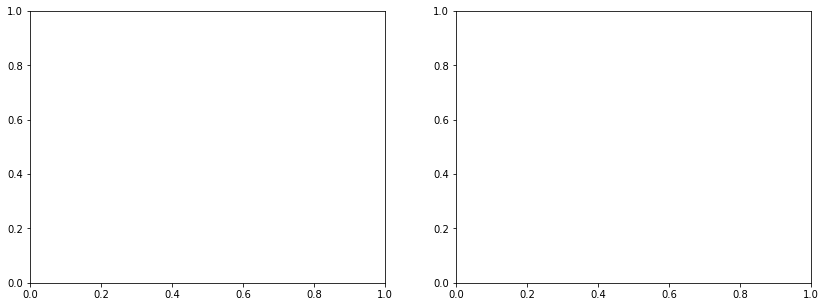

In [22]:
# ── Backtest visualization ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: MAE by checkpoint
ax = axes[0]
mae_data = []
for cp in BACKTEST_CHECKPOINTS:
    s = bt[bt["checkpoint"] == cp]
    if len(s) == 0:
        continue
    mae_data.append({
        "checkpoint": cp,
        "Model": mean_absolute_error(s["actual_T"], s["predicted_T"]),
        "Naive": mean_absolute_error(s["actual_T"], s["current_naive_T"]),
    })
mae_df = pd.DataFrame(mae_data)
ax.plot(mae_df["checkpoint"], mae_df["Model"], "o-", label="Model")
ax.plot(mae_df["checkpoint"], mae_df["Naive"], "s--", label="Naive (current avg)")
ax.set_xlabel("Reviews seen")
ax.set_ylabel("MAE")
ax.set_title("MAE vs. Reviews Seen")
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Predicted vs Actual scatter
ax = axes[1]
for cp in BACKTEST_CHECKPOINTS:
    s = bt[bt["checkpoint"] == cp]
    if len(s) == 0:
        continue
    ax.scatter(s["actual_T"], s["predicted_T"], alpha=0.4, s=20, label=f"{cp} reviews")
ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
ax.set_xlabel("Actual Tomatometer")
ax.set_ylabel("Predicted Tomatometer")
ax.set_title("Predicted vs Actual")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

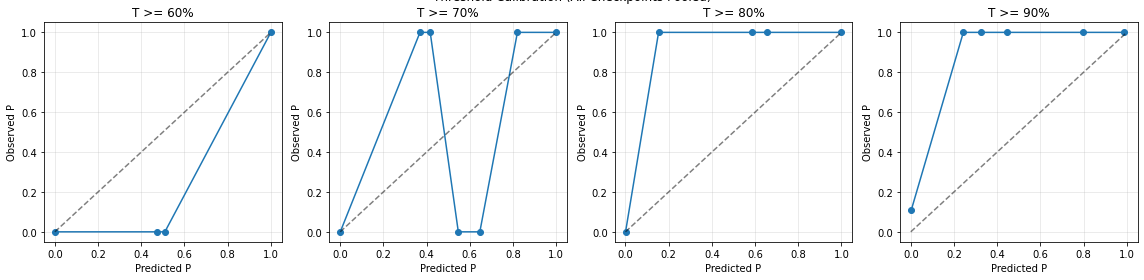

In [23]:
# ── Threshold calibration plots ───────────────────────────
fig, axes = plt.subplots(1, len(THRESHOLDS), figsize=(4 * len(THRESHOLDS), 4))
if len(THRESHOLDS) == 1:
    axes = [axes]

for ax, t in zip(axes, THRESHOLDS):
    t_int = int(t * 100)
    y_true = bt[f"actual_above_{t_int}"].values
    y_prob = bt[f"pred_prob_{t_int}"].values
    
    if len(np.unique(y_true)) < 2:
        ax.set_title(f">={t_int}% (insufficient data)")
        continue
    
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=8)
    ax.plot(prob_pred, prob_true, "o-", label="Model")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
    ax.set_xlabel("Predicted P")
    ax.set_ylabel("Observed P")
    ax.set_title(f"T >= {t_int}%")
    ax.grid(True, alpha=0.3)

fig.suptitle("Threshold Calibration (All Checkpoints Pooled)", y=1.02)
plt.tight_layout()
plt.show()

## 11. Worked Example: Full Nowcast Timeline

In [24]:
# ── Pick a well-reviewed validation movie for the worked example ──
val_stats = movie_stats[movie_stats["movie_key"].isin(val_movies)].copy()
val_stats = val_stats.sort_values("n_reviews", ascending=False)

# Pick top movie by review count
example_mk = val_stats.iloc[0]["movie_key"]
example_actual_T = val_stats.iloc[0]["tomatometer"]
example_n = int(val_stats.iloc[0]["n_reviews"])

print(f"Worked example movie: {example_mk}")
print(f"Total reviews: {example_n}")
print(f"Actual final Tomatometer: {example_actual_T:.1%}")
print()

# Get sorted reviews
ex_revs = df[df["movie_key"] == example_mk].sort_values("review_date")

# Define checkpoints
ex_checkpoints = [5, 10, 25, 50, 100]
ex_checkpoints = [cp for cp in ex_checkpoints if cp <= len(ex_revs)]

timeline = []
for cp in ex_checkpoints:
    as_of = ex_revs.iloc[cp - 1]["review_date"]
    nc = nowcast_movie(example_mk, as_of, df, critic_features, movie_features_all, n_sims=5000)
    print_nowcast(nc)
    print(f"  ** Actual final Tomatometer: {example_actual_T:.1%} **")
    
    timeline.append({
        "reviews_seen": cp,
        "date": as_of,
        "current_T": nc["observed"]["current_T"],
        "predicted_T": nc["point_estimate"],
        "p5": nc["p5"],
        "p95": nc["p95"],
    })

Worked example movie: m/star_wars_the_rise_of_skywalker
Total reviews: 992
Actual final Tomatometer: 50.8%


  NOWCAST: m/star_wars_the_rise_of_skywalker
  As of:   2019-12-18 00:00:00
  Observed: 115/203 Fresh  (current 56.7%)
  Remaining critics in universe: 2806

  Point estimate (mean): 57.6%
  Median:                57.5%
  90% CI:  [56.0%, 59.1%]
  50% CI:  [56.9%, 58.2%]
  Std dev:               0.009

  Threshold probabilities:
    P(T >= 60%): 0.5%
    P(T >= 70%): 0.0%
    P(T >= 80%): 0.0%
    P(T >= 90%): 0.0%
  ** Actual final Tomatometer: 50.8% **

  NOWCAST: m/star_wars_the_rise_of_skywalker
  As of:   2019-12-18 00:00:00
  Observed: 115/203 Fresh  (current 56.7%)
  Remaining critics in universe: 2806

  Point estimate (mean): 57.6%
  Median:                57.5%
  90% CI:  [56.0%, 59.1%]
  50% CI:  [56.9%, 58.2%]
  Std dev:               0.009

  Threshold probabilities:
    P(T >= 60%): 0.5%
    P(T >= 70%): 0.0%
    P(T >= 80%): 0.0%
    P(T >= 90%): 0.0%
  ** Actual 

ValueError: Multi-dimensional indexing (e.g. `obj[:, None]`) is no longer supported. Convert to a numpy array before indexing instead.

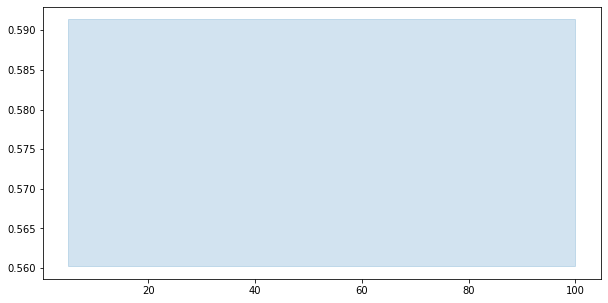

In [25]:
# ── Timeline visualization ────────────────────────────────
if len(timeline) > 1:
    tl = pd.DataFrame(timeline)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    
    ax.fill_between(tl["reviews_seen"], tl["p5"], tl["p95"],
                    alpha=0.2, color="C0", label="90% CI")
    ax.plot(tl["reviews_seen"], tl["predicted_T"], "o-", color="C0",
            label="Model prediction", linewidth=2)
    ax.plot(tl["reviews_seen"], tl["current_T"], "s--", color="C1",
            label="Naive (current avg)", linewidth=1.5)
    ax.axhline(y=example_actual_T, color="red", linestyle=":",
               linewidth=2, label=f"Actual ({example_actual_T:.0%})")
    
    ax.set_xlabel("Number of reviews seen")
    ax.set_ylabel("Tomatometer")
    ax.set_title(f"Nowcast Timeline: {example_mk}")
    ax.legend()
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough checkpoints for a timeline plot.")

In [ ]:
# ── Histogram of final simulation at earliest checkpoint ──
if len(ex_checkpoints) > 0:
    early_cp = ex_checkpoints[0]
    as_of = ex_revs.iloc[early_cp - 1]["review_date"]
    nc = nowcast_movie(example_mk, as_of, df, critic_features, movie_features_all, n_sims=10000)
    
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(nc["simulations"], bins=50, density=True, alpha=0.7, color="C0",
            edgecolor="white")
    ax.axvline(x=example_actual_T, color="red", linestyle="--", linewidth=2,
               label=f"Actual ({example_actual_T:.0%})")
    ax.axvline(x=nc["point_estimate"], color="C0", linestyle="-", linewidth=2,
               label=f"Predicted ({nc['point_estimate']:.0%})")
    
    # Mark thresholds
    for t in THRESHOLDS:
        p = nc["threshold_probs"][t]
        ax.axvline(x=t, color="gray", linestyle=":", alpha=0.5)
        ax.text(t, ax.get_ylim()[1] * 0.9, f"{t:.0%}\nP={p:.0%}",
                ha="center", fontsize=8)
    
    ax.set_xlabel("Simulated Final Tomatometer")
    ax.set_ylabel("Density")
    ax.set_title(f"Monte Carlo Distribution after {early_cp} reviews — {example_mk}")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 12. Summary

In [26]:
# ── Summary table of backtest results ─────────────────────
summary_rows = []
for cp in BACKTEST_CHECKPOINTS:
    s = bt[bt["checkpoint"] == cp]
    if len(s) == 0:
        continue
    row = {
        "Reviews Seen": cp,
        "N Movies": len(s),
        "Model MAE": f"{mean_absolute_error(s['actual_T'], s['predicted_T']):.4f}",
        "Naive MAE": f"{mean_absolute_error(s['actual_T'], s['current_naive_T']):.4f}",
        "Model RMSE": f"{np.sqrt(mean_squared_error(s['actual_T'], s['predicted_T'])):.4f}",
        "Naive RMSE": f"{np.sqrt(mean_squared_error(s['actual_T'], s['current_naive_T'])):.4f}",
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print("BACKTEST SUMMARY")
print("=" * 80)
print(summary_df.to_string(index=False))
print("\nBrier scores by threshold:")
print(brier_df.to_string(index=False))
print("\n" + "=" * 80)
print("Model compares predicted final Tomatometer against the naive baseline")
print("(which simply uses the current average of observed reviews).")
print("Lower MAE/RMSE/Brier = better.")

BACKTEST SUMMARY
 Reviews Seen  N Movies Model MAE Naive MAE Model RMSE Naive RMSE
            5       100    0.0227    0.1198     0.0314     0.1597
           10       100    0.0227    0.0912     0.0314     0.1235
           25        91    0.0220    0.0507     0.0304     0.0717
           50        65    0.0196    0.0322     0.0282     0.0492

Brier scores by threshold:
 checkpoint   n Brier_>=60% Brier_>=70% Brier_>=80% Brier_>=90%
          5 100      0.0023      0.0106      0.0105      0.1075
         10 100      0.0023      0.0107      0.0106      0.1074
         25  91      0.0028      0.0123      0.0112      0.1066
         50  65      0.0041      0.0065      0.0164      0.0900

Model compares predicted final Tomatometer against the naive baseline
(which simply uses the current average of observed reviews).
Lower MAE/RMSE/Brier = better.


In [27]:
print("Notebook complete.")
print(f"\nDataset: {CSV_PATH}")
print(f"Train movies: {len(train_movies):,} | Val movies: {len(val_movies):,}")
print(f"Critic universe: {n_critics:,}")
print(f"Cutoff date: {CUTOFF_DATE}")
print(f"\nTo nowcast a specific movie:")
print(f'  result = nowcast_movie("m/movie_slug", "2019-06-15", df, critic_features, movie_features_all)')
print(f'  print_nowcast(result)')

Notebook complete.

Dataset: rotten_tomatoes_critic_reviews.csv
Train movies: 10,501 | Val movies: 559
Critic universe: 3,000
Cutoff date: 2019-01-01

To nowcast a specific movie:
  result = nowcast_movie("m/movie_slug", "2019-06-15", df, critic_features, movie_features_all)
  print_nowcast(result)
